In [4]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

In [5]:
flat_data = fits.getdata('data/flat.fits')
moon_data = fits.getdata('data/moon.fits')

print(flat_data.shape) #confirming the shape of both fits files
print(moon_data.shape)

(4112, 385)
(4112, 385)


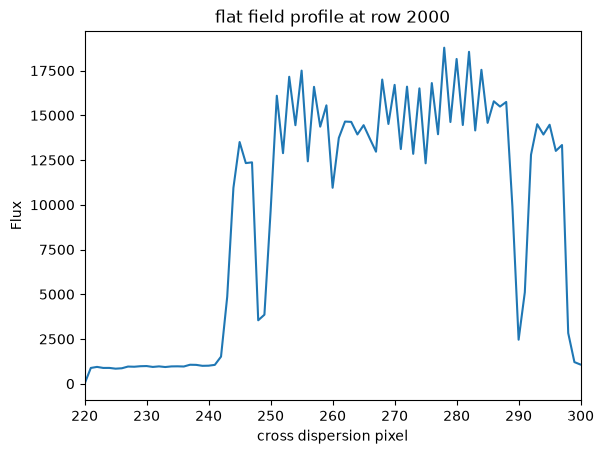

In [9]:
#looking at what we are trying to find

test_row = 2000

plt.plot(flat_data[test_row, :])
plt.xlim(220,300)
plt.xlabel('cross dispersion pixel')
plt.ylabel('Flux')
plt.title("flat field profile at row 2000")
plt.show()

Smooth out field first to remove minor bumps

In [10]:
from scipy.signal import find_peaks

In [24]:
row = flat_data[2000, :]

search_region = slice(220, 300)
row_segment = row[search_region]

#finding dips
inverted = -row_segment
peaks,properties = find_peaks(inverted, prominence=8000)

#converting back to pixel coordinates
dip_positions = peaks + 220

print("Detected dip positions:", dip_positions)
print("Prominences:", properties['prominences'])

Detected dip positions: [248 290]
Prominences: [ 9964. 12044.]


This proves that this smoothing method works so now we can loop it over every row

In [58]:
n_rows = flat_data.shape[0]
tramline1 = np.full(n_rows, np.nan)
tramline2 = np.full(n_rows, np.nan)

min_signal_threshold = 1000 #this allows us to skip rows with no illumination 
for i in range(n_rows):
    row_segment = flat_data[i,:]
    if row_segment.max() < min_signal_threshold:
        continue
        
    inverted = -row_segment
    relative_prominence = 0.1*row_segment.max()
    peaks,properties = find_peaks(inverted, prominence=relative_prominence)
    dip_positions = peaks
    
    if len(peaks) >= 2:
        top2_idx = np.argsort(properties['prominences'])[-2:]
        top2_peaks = np.sort(peaks[top2_idx]) 
        tramline1[i] = top2_peaks[0] 
        tramline2[i] = top2_peaks[1] 

Now plotting the detected tramlines

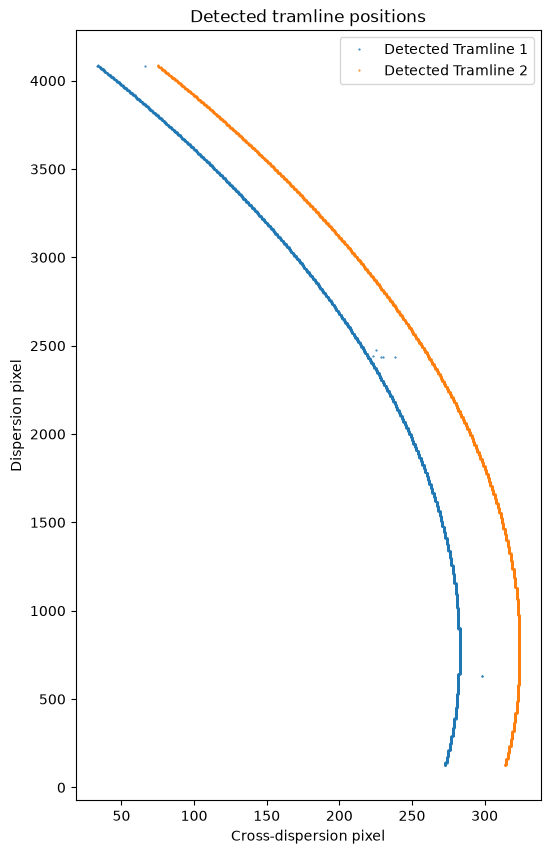

In [59]:
rows = np.arange(n_rows)

plt.figure(figsize=(6, 10))
plt.plot(tramline1, rows, '.', markersize=1, label='Detected Tramline 1')
plt.plot(tramline2, rows, '.', markersize=1, label='Detected Tramline 2')
plt.xlabel('Cross-dispersion pixel')
plt.ylabel('Dispersion pixel')
plt.title('Detected tramline positions')
plt.legend()
plt.show()

In [60]:
valid1 = ~np.isnan(tramline1)
valid2 = ~np.isnan(tramline2)

coeffs1 = np.polyfit(rows[valid1], tramline1[valid1], 3)
coeffs2 = np.polyfit(rows[valid2], tramline2[valid2], 3)

fit_rows = np.arange(rows[valid1].min(), rows[valid1].max()+1)
fit1 = np.polyval(coeffs1, fit_rows)
fit2 = np.polyval(coeffs2, fit_rows)

Valid1/2 - masks any issues where nothing is detected so only real rows are used for fitting.
Coeffs1/2 - describing each tramline's position as a function of dispersion row -> polyfit finding best cubic coefficients
Fit rows - defines complete continuous range of rows
fit1/2 -smooths tramline curve

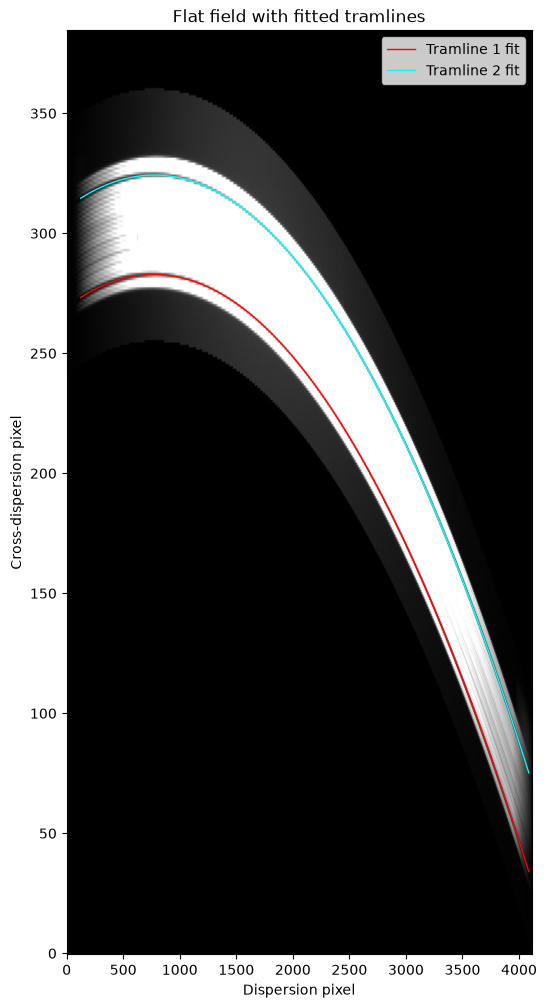

In [61]:
plt.figure(figsize=(6, 12))
plt.imshow(flat_data.T, origin='lower', aspect='auto', cmap='gray', vmin=0, vmax=5000)
plt.plot(fit_rows, fit1, color='red', linewidth=1, label='Tramline 1 fit')
plt.plot(fit_rows, fit2, color='cyan', linewidth=1, label='Tramline 2 fit')
plt.xlabel('Dispersion pixel')
plt.ylabel('Cross-dispersion pixel')
plt.title('Flat field with fitted tramlines')
plt.legend()
plt.savefig('figures/task4_tramlines.png', dpi=150)
plt.show()

Plot overlayed with actual data

Explanation of Approach -

To locate the low illumination dips with the fibre bundle, each row of the flat field was searched independently using the scipy find peaks package. This was applied to the inverted profile so that dips were detectable "peaks".
A relative prominence threshold was used (10% of each rows peak brightness) so that detection scaled natrually with each illumination leve. Initially it was planned to do one prominence threshold however a large fraction of rows failes due to fainter tramlines or the threshold being too strict towards the edges.
THe other issue was that some rows had more thna 2 peaks, so to fix this only the two dips with the highest prominence were maintained, this made the method more robust across a full range of brightness.
Once all rows had been successfully handles a cubic polynomial was fit to each tramlines position as a function of dispersion row. A low order polynomial was chosen as the tramlines showed a single gentre curve across the detector.



